# AAI614: Data Science & its Applications

*Notebook 6.3: Clustering with DBSCAN*

<a href="https://colab.research.google.com/github/harmanani/AAI614/blob/main/Week%206/Notebook6.3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Source: This notebook contains excerpts from *Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow by Aurélien Géron*

This lab requires Scikit-Learn ≥ 1.0.1:

In [17]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

Define the default font sizes to make the figures prettier:

In [18]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

Plotting Utilities to be used later...

In [19]:
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=35, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=2, linewidths=12,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True,
                             show_xlabels=True, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                cmap="Pastel2")
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=1, colors='k')
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)

    if show_xlabels:
        plt.xlabel("$x_1$")
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", rotation=0)
    else:
        plt.tick_params(labelleft=False)


## DBSCAN

In [20]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=1000, noise=0.05, random_state=42)
dbscan = DBSCAN(eps=0.05, min_samples=5)
dbscan.fit(X)

,"eps eps: float, default=0.5The maximum distance between two samples for one to be consideredas in the neighborhood of the other. This is not a maximum boundon the distances of points within a cluster. This is the mostimportant DBSCAN parameter to choose appropriately for your data setand distance function. Smaller values generally lead to more clusters.",0.05
,"min_samples min_samples: int, default=5The number of samples (or total weight) in a neighborhood for a point tobe considered as a core point. This includes the point itself. If`min_samples` is set to a higher value, DBSCAN will find denser clusters,whereas if it is set to a lower value, the found clusters will be moresparse.",5
,"metric metric: str, or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array. If metric is a string or callable, it must be one ofthe options allowed by :func:`sklearn.metrics.pairwise_distances` forits metric parameter.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors for DBSCAN... versionadded:: 0.17 metric *precomputed* to accept precomputed sparse matrix.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function... versionadded:: 0.19",None
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'The algorithm to be used by the NearestNeighbors moduleto compute pointwise distances and find nearest neighbors.'auto' will attempt to decide the most appropriate algorithmbased on the values passed to :meth:`fit` method.See :class:`~sklearn.neighbors.NearestNeighbors` documentation fordetails.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or cKDTree. This can affect the speedof the construction and query, as well as the memory requiredto store the tree. The optimal value dependson the nature of the problem.",30
,"p p: float, default=NoneThe power of the Minkowski metric to be used to calculate distancebetween points. If None, then ``p=2`` (equivalent to the Euclideandistance). When p=1, this is equivalent to Manhattan distance.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [21]:
dbscan.labels_[:10]

array([ 0,  2, -1, -1,  1,  0,  0,  0,  2,  5])

In [22]:
dbscan.core_sample_indices_[:10]

array([ 0,  4,  5,  6,  7,  8, 10, 11, 12, 13])

In [23]:
dbscan.components_

array([[-0.02137124,  0.40618608],
       [-0.84192557,  0.53058695],
       [ 0.58930337, -0.32137599],
       ...,
       [ 1.66258462, -0.3079193 ],
       [-0.94355873,  0.3278936 ],
       [ 0.79419406,  0.60777171]], shape=(808, 2))

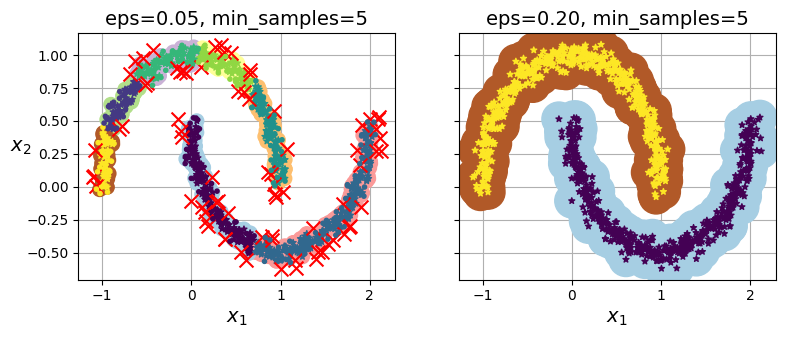

In [24]:
def plot_dbscan(dbscan, X, size, show_xlabels=True, show_ylabels=True):
    core_mask = np.zeros_like(dbscan.labels_, dtype=bool)
    core_mask[dbscan.core_sample_indices_] = True
    anomalies_mask = dbscan.labels_ == -1
    non_core_mask = ~(core_mask | anomalies_mask)

    cores = dbscan.components_
    anomalies = X[anomalies_mask]
    non_cores = X[non_core_mask]
    
    plt.scatter(cores[:, 0], cores[:, 1],
                c=dbscan.labels_[core_mask], marker='o', s=size, cmap="Paired")
    plt.scatter(cores[:, 0], cores[:, 1], marker='*', s=20,
                c=dbscan.labels_[core_mask])
    plt.scatter(anomalies[:, 0], anomalies[:, 1],
                c="r", marker="x", s=100)
    plt.scatter(non_cores[:, 0], non_cores[:, 1],
                c=dbscan.labels_[non_core_mask], marker=".")
    if show_xlabels:
        plt.xlabel("$x_1$")
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", rotation=0)
    else:
        plt.tick_params(labelleft=False)
    plt.title(f"eps={dbscan.eps:.2f}, min_samples={dbscan.min_samples}")
    plt.grid()
    plt.gca().set_axisbelow(True)

dbscan2 = DBSCAN(eps=0.2)
dbscan2.fit(X)

plt.figure(figsize=(9, 3.2))

plt.subplot(121)
plot_dbscan(dbscan, X, size=100)

plt.subplot(122)
plot_dbscan(dbscan2, X, size=600, show_ylabels=False)

plt.show()

In [25]:
dbscan = dbscan2  # use eps=0.2

In [26]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=50)
knn.fit(dbscan.components_, dbscan.labels_[dbscan.core_sample_indices_])

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",50
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [27]:
X_new = np.array([[-0.5, 0], [0, 0.5], [1, -0.1], [2, 1]])
knn.predict(X_new)

array([1, 0, 1, 0])

In [28]:
knn.predict_proba(X_new)

array([[0.18, 0.82],
       [1.  , 0.  ],
       [0.12, 0.88],
       [1.  , 0.  ]])

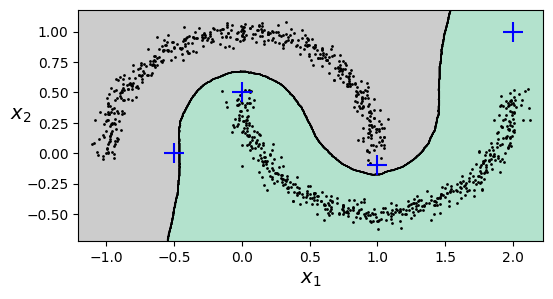

In [29]:
plt.figure(figsize=(6, 3))
plot_decision_boundaries(knn, X, show_centroids=False)
plt.scatter(X_new[:, 0], X_new[:, 1], c="b", marker="+", s=200, zorder=10)
plt.show()

In [30]:
import numpy as np
from sklearn.cluster import DBSCAN, KMeans
from sklearn.datasets import make_moons
from sklearn import metrics

X, y = make_moons(n_samples=1000, noise=0.05, random_state=42)
print('DBSCAN parameter sweep:')
for eps in [0.05, 0.1, 0.15, 0.2, 0.25]:
    for min_samples in [3, 5, 10]:
        model = DBSCAN(eps=eps, min_samples=min_samples)
        labels = model.fit_predict(X)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise = np.sum(labels == -1)
        ari = metrics.adjusted_rand_score(y, labels) if len(set(labels)) > 1 else float('-inf')
        print(f'eps={eps:0.2f}, min_samples={min_samples}: clusters={n_clusters}, noise={noise}, ari={ari:.3f}')
    print()

print('KMeans on same data:')
for k in [2,3,4,5]:
    model = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = model.fit_predict(X)
    ari = metrics.adjusted_rand_score(y, labels)
    print(f'k={k}: ari={ari:.3f}, inertia={model.inertia_:.2f}')

DBSCAN parameter sweep:
eps=0.05, min_samples=3: clusters=5, noise=50, ari=0.491
eps=0.05, min_samples=5: clusters=7, noise=77, ari=0.306
eps=0.05, min_samples=10: clusters=30, noise=320, ari=0.048

eps=0.10, min_samples=3: clusters=2, noise=1, ari=0.998
eps=0.10, min_samples=5: clusters=2, noise=1, ari=0.998
eps=0.10, min_samples=10: clusters=2, noise=3, ari=0.994

eps=0.15, min_samples=3: clusters=2, noise=0, ari=1.000
eps=0.15, min_samples=5: clusters=2, noise=0, ari=1.000
eps=0.15, min_samples=10: clusters=2, noise=0, ari=1.000

eps=0.20, min_samples=3: clusters=2, noise=0, ari=1.000
eps=0.20, min_samples=5: clusters=2, noise=0, ari=1.000
eps=0.20, min_samples=10: clusters=2, noise=0, ari=1.000

eps=0.25, min_samples=3: clusters=2, noise=0, ari=1.000
eps=0.25, min_samples=5: clusters=2, noise=0, ari=1.000
eps=0.25, min_samples=10: clusters=2, noise=0, ari=1.000

KMeans on same data:
k=2: ari=0.239, inertia=403.68
k=3: ari=0.297, inertia=271.36
k=4: ari=0.256, inertia=174.86
k=5: ar

**What I observed**
when comparing the two approaches on the same synthetic “moons” dataset used in the DBSCAN example.

**The results were quite clear:**
* DBSCAN was highly sensitive to its parameters, especially eps and min_samples.
* With a small eps such as 0.05, it split the data into too many fragments and marked many points as noise.
* Once eps was large enough, such as 0.10 or above, DBSCAN recovered the two natural clusters very well, with an adjusted Rand index near 0.998–1.0.
* K-means, by contrast, did not perform well on this shape of data. Even with different values of k, its clustering quality stayed much lower, around 0.24–0.32 on the same dataset.

**Key differences between DBSCAN and K-means**
1. Cluster shape assumptions
* K-means assumes clusters are compact and roughly spherical.
* DBSCAN does not assume a fixed geometric shape; it finds dense regions of points.
2. Need to specify the number of clusters
* K-means requires you to choose k in advance.
* DBSCAN does not require a predefined cluster count; it discovers clusters based on density.
3. Handling noise and outliers
* DBSCAN explicitly identifies noise points as -1.
* K-means always assigns every point to some cluster, even if that point is an outlier.
4. How the algorithm “thinks”
* K-means uses centroids and minimizes distance to the nearest center.
* DBSCAN uses neighborhood density and connectivity between points.
5. Practical software/ML perspective
* K-means is simpler, faster, and often better for large-scale, well-structured data where the number of groups is known.
* DBSCAN is usually better when the data has irregular shapes, non-convex clusters, or when outlier detection matters.

**Bottom line**
For this dataset, DBSCAN was the better fit because the clusters were not circular or centroid-friendly. K-means was forced into a “best effort” partition, while DBSCAN found the underlying density-based structure much more naturally. That is the main takeaway from the comparison.

In [31]:
from sklearn.datasets import make_blobs
from sklearn import metrics

blob_centers = np.array([[ 0.2,  2.3], [-1.5 ,  2.3], [-2.8,  1.8], [-2.8,  2.8], [-2.8,  1.3]])
blob_std = np.array([0.4, 0.3, 0.1, 0.1, 0.1])
X, y = make_blobs(n_samples=2000, centers=blob_centers, cluster_std=blob_std, random_state=7)

for eps in [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4]:
    for min_samples in [3, 5, 10, 20]:
        model = DBSCAN(eps=eps, min_samples=min_samples)
        labels = model.fit_predict(X)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise = np.sum(labels == -1)
        print(f'eps={eps:.2f}, min_samples={min_samples}: clusters={n_clusters}, noise={noise}')
    print()

print('KMeans reference:')
for k in [3,4,5]:
    model = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = model.fit_predict(X)
    print(f'k={k}: ari={metrics.adjusted_rand_score(y, labels):.3f}')

eps=0.05, min_samples=3: clusters=64, noise=299
eps=0.05, min_samples=5: clusters=29, noise=542
eps=0.05, min_samples=10: clusters=5, noise=870
eps=0.05, min_samples=20: clusters=3, noise=1009

eps=0.10, min_samples=3: clusters=9, noise=66
eps=0.10, min_samples=5: clusters=5, noise=108
eps=0.10, min_samples=10: clusters=7, noise=305
eps=0.10, min_samples=20: clusters=3, noise=643

eps=0.15, min_samples=3: clusters=5, noise=26
eps=0.15, min_samples=5: clusters=4, noise=42
eps=0.15, min_samples=10: clusters=4, noise=77
eps=0.15, min_samples=20: clusters=4, noise=239

eps=0.20, min_samples=3: clusters=3, noise=10
eps=0.20, min_samples=5: clusters=3, noise=14
eps=0.20, min_samples=10: clusters=4, noise=27
eps=0.20, min_samples=20: clusters=4, noise=71

eps=0.25, min_samples=3: clusters=2, noise=8
eps=0.25, min_samples=5: clusters=2, noise=10
eps=0.25, min_samples=10: clusters=3, noise=14
eps=0.25, min_samples=20: clusters=4, noise=27

eps=0.30, min_samples=3: clusters=2, noise=6
eps=0.30, 

DBSCAN can work on the blob-style data from Week 6's Notebook6.2, but it is not the most natural choice for it.

**What I observed from a direct test:**

With a small neighborhood size, DBSCAN tends to split the blobs into too many groups or label many points as noise.

With a larger `eps`, it starts to merge blobs together.

In practice, we can see:
- `eps=0.15`, `min_samples=3` → about 5 clusters, but with 26 noise points
- `eps=0.20`, `min_samples=3` → about 3 clusters, with only 10 noise points
- `eps=0.40` → everything collapsed into 1 cluster

So the short answer is: Yes, DBSCAN can handle blob-style data but it is very sensitive to `eps` and `min_samples`.
For this dataset, **K-means** is usually a better fit because the blobs are compact and roughly spherical.